In [28]:
# packages
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import os

In [29]:
# Load data
abs_error = np.load("plot-data/abs_error.npy")
adam_epochs = np.load("plot-data/adam_epochs.npy")
adam_loss_history = np.load("plot-data/adam_loss_history.npy")
adam_metric_epochs = np.load("plot-data/adam_metric_epochs.npy")
adam_rel_l2_errors = np.load("plot-data/adam_rel_l2_errors.npy")
r = np.load("plot-data/r.npy")
rel_error = np.load("plot-data/rel_error.npy")
ssb_epochs = np.load("plot-data/ssb_epochs.npy")
ssb_loss_history = np.load("plot-data/ssb_loss_history.npy")
ssb_metric_epochs = np.load("plot-data/ssb_metric_epochs.npy")
ssb_metric_history = np.load("plot-data/ssb_metric_history.npy")
u_exact = np.load("plot-data/u_exact.npy")
u_pred = np.load("plot-data/u_pred.npy")
final_l2_error = rel_error[-1][0]
epochs_adam = len(adam_epochs)
epochs_ssb = len(ssb_epochs)

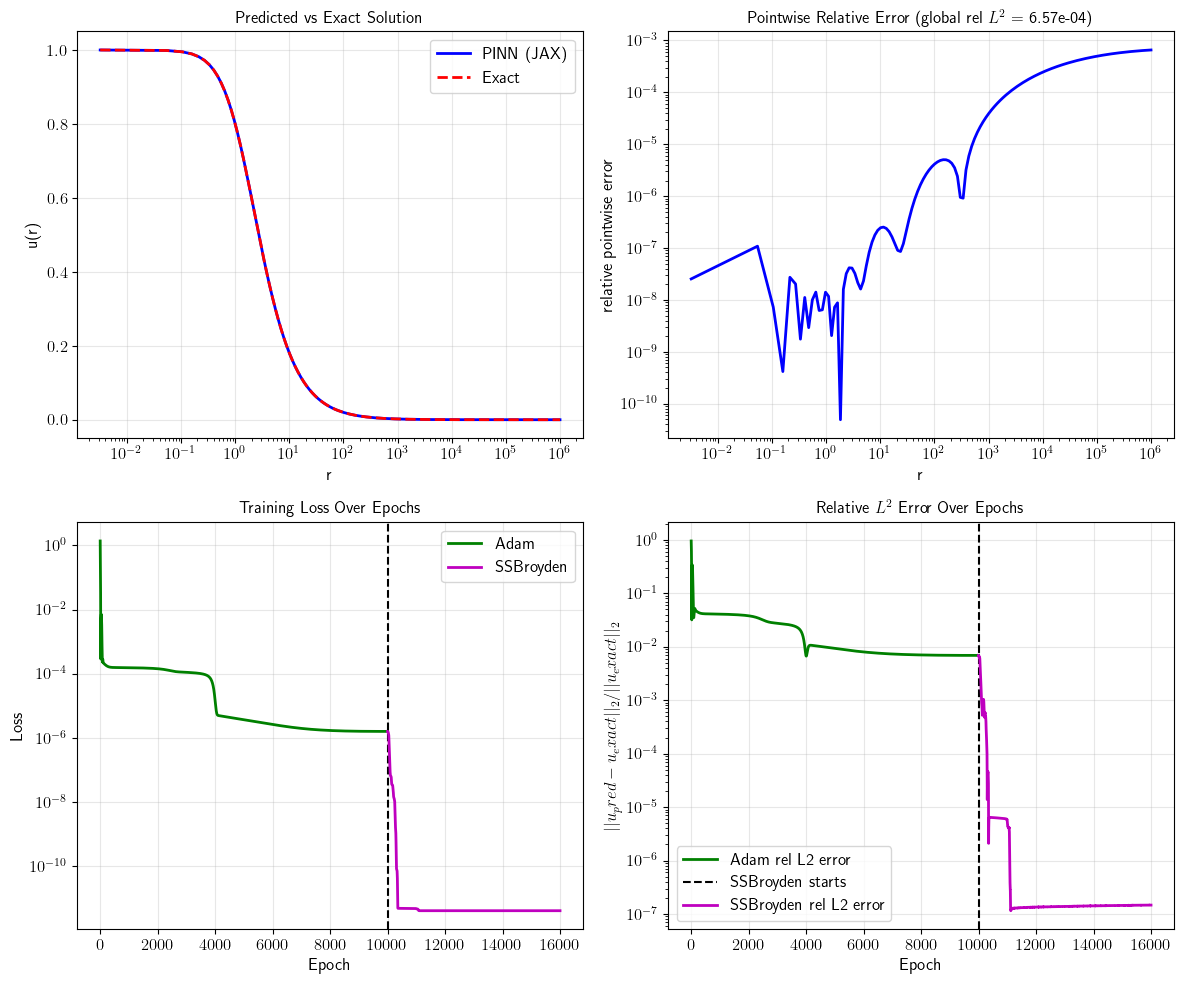

In [36]:
# Plot in the same 2x2 layout used in pinndorama_ssbroyden.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Predicted vs exact solution.
axes[0, 0].plot(r, u_pred, "b-", label="PINN (JAX)", linewidth=2)
axes[0, 0].plot(r, u_exact, "r--", label="Exact", linewidth=2)
axes[0, 0].set_xlabel("r")
axes[0, 0].set_ylabel("u(r)")
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Predicted vs Exact Solution")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Relative error over domain.
axes[0, 1].plot(r, rel_error, "b-", linewidth=2)
axes[0, 1].set_xlabel("r")
axes[0, 1].set_ylabel("relative pointwise error")
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].set_title(fr"Pointwise Relative Error (global rel $L^2$ = {final_l2_error:.2e})")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Loss over epochs, split by Adam and SSBroyden.
if len(adam_loss_history) > 0:
    adam_epochs = np.arange(1, len(adam_loss_history) + 1)
    axes[1, 0].semilogy(adam_epochs, adam_loss_history, "g-", linewidth=2, label="Adam")
    axes[1, 0].axvline(epochs_adam, color="k", linestyle="--", linewidth=1.5)

if len(ssb_loss_history) > 0:
    ssb_epochs = epochs_adam + np.arange(1, len(ssb_loss_history) + 1)
    axes[1, 0].semilogy(ssb_epochs, ssb_loss_history, "m-", linewidth=2, label="SSBroyden")

axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].set_title("Training Loss Over Epochs")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Relative L2 over epochs, split by Adam and SSBroyden.
if len(adam_rel_l2_errors) > 0:
    adam_metric_epochs = np.arange(1, len(adam_rel_l2_errors) + 1)
    axes[1, 1].semilogy(adam_metric_epochs, adam_rel_l2_errors, "g-", linewidth=2, label="Adam rel L2 error")
    axes[1, 1].axvline(epochs_adam, color="k", linestyle="--", linewidth=1.5, label="SSBroyden starts")

if len(ssb_metric_history) > 0:
    ssb_metric_epochs = epochs_adam + np.arange(1, len(ssb_metric_history) + 1)
    axes[1, 1].semilogy(ssb_metric_epochs, ssb_metric_history, "m-", linewidth=2, label="SSBroyden rel L2 error")

# format plot
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel(r"$||u_pred - u_exact||_2 / ||u_exact||_2$")
axes[1, 1].set_title(r"Relative $L^2$ Error Over Epochs")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
plt.tight_layout()

# save the plot
plt.savefig("all_plots.pdf")